In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# -------------------------------
# Augmentation 函數 (強/弱版本)
# -------------------------------
def weak_augmentation(x, noise_std=0.01):
    # 弱增強：加入少量高斯雜訊
    noise = torch.randn_like(x) * noise_std
    return x + noise

def strong_augmentation(x, noise_std=0.05, mask_prob=0.1):
    # 強增強：加入較大高斯雜訊並隨機遮蔽部分時間點
    noise = torch.randn_like(x) * noise_std
    x_aug = x + noise
    mask = (torch.rand(x.shape[0], x.shape[1]) < mask_prob).unsqueeze(-1).to(x.device)
    # 用零值填補 masked 位置
    x_aug = x_aug.masked_fill(mask, 0.)
    return x_aug

# -------------------------------
# Encoder Backbone 定義
# -------------------------------
class TimeSeriesEncoder(nn.Module):
    def __init__(self, input_dim, cnn_channels, kernel_size, transformer_dim, nhead, num_transformer_layers, latent_dim):
        super(TimeSeriesEncoder, self).__init__()
        # CNN 層提取局部統計特徵
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=input_dim, out_channels=cnn_channels, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(),
            nn.Conv1d(in_channels=cnn_channels, out_channels=cnn_channels, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU()
        )
        # Transformer Encoder 捕捉全局依賴性
        encoder_layer = nn.TransformerEncoderLayer(d_model=cnn_channels, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        # 最後映射到 latent space
        self.fc = nn.Linear(cnn_channels, latent_dim)
        
    def forward(self, x):
        # x: (B, T, F) -> 轉換成 (B, F, T) 供 CNN 使用
        x = x.transpose(1, 2)  # (B, F, T)
        cnn_feat = self.cnn(x)  # (B, cnn_channels, T)
        # 再轉回 (B, T, cnn_channels) 給 Transformer
        cnn_feat = cnn_feat.transpose(1, 2)  # (B, T, cnn_channels)
        transformer_feat = self.transformer(cnn_feat)  # (B, T, cnn_channels)
        # Global average pooling over time dimension
        pooled = transformer_feat.mean(dim=1)  # (B, cnn_channels)
        latent = self.fc(pooled)  # (B, latent_dim)
        return latent, transformer_feat  # 同時回傳 transformer 層所有時間點的特徵，用於 masked prediction

# -------------------------------
# Masked Timestamp Prediction Head
# -------------------------------
class MaskedTimestampHead(nn.Module):
    def __init__(self, d_model, output_dim):
        super(MaskedTimestampHead, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, output_dim)
        )
        
    def forward(self, x):
        # x: (B, d_model)
        return self.fc(x)

# -------------------------------
# 整體模型
# -------------------------------
class TimeSeriesRepresentationModel(nn.Module):
    def __init__(self, input_dim, cnn_channels, kernel_size, transformer_dim, nhead, num_transformer_layers, latent_dim):
        super(TimeSeriesRepresentationModel, self).__init__()
        self.encoder = TimeSeriesEncoder(input_dim, cnn_channels, kernel_size, transformer_dim, nhead, num_transformer_layers, latent_dim)
        # Masked prediction head 用來預測被 mask 掉的時間點值
        self.mask_head = MaskedTimestampHead(cnn_channels, input_dim)
        
    def forward(self, x, mask_indices=None):
        """
        x: (B, T, input_dim)
        mask_indices: (B, T) Bool Tensor, True 表示該位置被 mask，需要預測
        """
        latent, transformer_feat = self.encoder(x)  # latent: (B, latent_dim), transformer_feat: (B, T, cnn_channels)
        
        masked_pred = None
        if mask_indices is not None:
            # 取得被 mask 的位置的 transformer 特徵
            # 將 transformer_feat reshape 成 (B*T, cnn_channels)
            B, T, D = transformer_feat.shape
            transformer_feat_flat = transformer_feat.view(B*T, D)
            mask_indices_flat = mask_indices.view(B*T)  # (B*T,)
            # 僅預測被 mask 的位置
            masked_feat = transformer_feat_flat[mask_indices_flat]
            masked_pred = self.mask_head(masked_feat)  # (num_masked, input_dim)
            
        return latent, masked_pred

# -------------------------------
# Contrastive Loss (NX-XENT Loss)
# -------------------------------
def nt_xent_loss(z1, z2, temperature=0.5):
    """
    z1, z2: (B, latent_dim)，來自不同 augmentation 的 embedding
    """
    B = z1.shape[0]
    z1_norm = F.normalize(z1, dim=1)
    z2_norm = F.normalize(z2, dim=1)
    
    representations = torch.cat([z1_norm, z2_norm], dim=0)  # (2B, latent_dim)
    similarity_matrix = torch.matmul(representations, representations.T)  # (2B, 2B)
    
    # 建立 labels (對角線 mask 除外)
    labels = torch.cat([torch.arange(B) for _ in range(2)], dim=0)
    labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float().to(z1.device)
    
    # 移除自身相似性
    mask = torch.eye(labels.shape[0], device=z1.device).bool()
    labels = labels.masked_fill(mask, 0)
    
    # 溫度縮放
    similarity_matrix = similarity_matrix / temperature
    # 計算 NX-XENT Loss
    loss = F.cross_entropy(similarity_matrix, labels.argmax(dim=1))
    # ※ 這裡簡化了實作，實際上可參考 SimCLR 實作來處理正負樣本
    return loss

# -------------------------------
# Training Process
# -------------------------------
def train(model, dataloader, optimizer, device, temperature=0.5, mask_prob=0.15, lambda_mask=1.0, lambda_contrast=1.0):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        # 假設 batch 是一個 dict，包含 key: 'ts' -> 原始時間序列 Tensor, shape (B, T, input_dim)
        x = batch['ts'].to(device)
        B, T, feature_dim = x.shape  # 這裡改用 feature_dim 避免覆蓋 torch.nn.functional (F)
        
        # 產生 mask index (針對 masked prediction)
        mask_indices = (torch.rand(B, T) < mask_prob).to(device)
        
        # 產生 augmentation 版本
        x_weak = weak_augmentation(x)
        x_strong = strong_augmentation(x)
        
        # 前向運算：原始資料用於 masked prediction；augmented 用於 contrastive learning
        latent_orig, masked_pred = model(x, mask_indices=mask_indices)  # latent_orig: (B, latent_dim)
        latent_weak, _ = model(x_weak)
        latent_strong, _ = model(x_strong)
        
        # 計算 Masked Prediction Loss (MSE Loss)
        # 將真實數值 reshape 成 (B*T, input_dim)
        x_flat = x.view(B * T, feature_dim)
        mask_indices_flat = mask_indices.view(B * T)
        target_mask = x_flat[mask_indices_flat]
        if masked_pred is not None and target_mask.shape[0] > 0:
            loss_mask = F.mse_loss(masked_pred, target_mask)
        else:
            loss_mask = torch.tensor(0.0, device=device)
        
        # Contrastive Loss：利用 weak 與 strong 版本的 latent representation
        loss_contrast = nt_xent_loss(latent_weak, latent_strong, temperature)
        
        # 總損失
        loss = lambda_mask * loss_mask + lambda_contrast * loss_contrast
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(dataloader)
    return avg_loss

# -------------------------------
# 假設一個 DataLoader 的範例 (隨機生成資料)
# -------------------------------
from torch.utils.data import Dataset, DataLoader

class RandomTimeSeriesDataset(Dataset):
    def __init__(self, num_samples=1000, sequence_length=50, input_dim=1):
        self.num_samples = num_samples
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # 隨機生成一個時間序列
        ts = np.random.randn(self.sequence_length, self.input_dim).astype(np.float32)
        return {'ts': torch.tensor(ts)}

# -------------------------------
# 主程式
# -------------------------------
if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 超參數設定
    input_dim = 1           # 時間序列的特徵數，這裡假設為單變數
    cnn_channels = 64
    kernel_size = 3
    transformer_dim = cnn_channels  # 需與 CNN 輸出一致
    nhead = 4
    num_transformer_layers = 2
    latent_dim = 2
    batch_size = 32
    num_epochs = 10
    learning_rate = 1e-3
    
    # 建立 dataset 與 dataloader
    dataset = RandomTimeSeriesDataset(num_samples=1000, sequence_length=50, input_dim=input_dim)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # 模型與 optimizer
    model = TimeSeriesRepresentationModel(input_dim, cnn_channels, kernel_size, transformer_dim, nhead, num_transformer_layers, latent_dim)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # 訓練迴圈
    for epoch in range(num_epochs):
        avg_loss = train(model, dataloader, optimizer, device)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")
    
    # 推論：給定新的時間序列，取得 latent representation
    model.eval()
    with torch.no_grad():
        sample = next(iter(dataloader))['ts'].to(device)  # (B, T, input_dim)
        latent, _ = model(sample)
        print("Latent Representation shape:", latent.shape)


Epoch [1/10], Loss: 4.2804
Epoch [2/10], Loss: 4.0896
Epoch [3/10], Loss: 3.8293
Epoch [4/10], Loss: 3.5426
Epoch [5/10], Loss: 3.3480
Epoch [6/10], Loss: 3.3167
Epoch [7/10], Loss: 3.2969
Epoch [8/10], Loss: 3.3102
Epoch [9/10], Loss: 3.3327
Epoch [10/10], Loss: 3.3216
Latent Representation shape: torch.Size([32, 2])


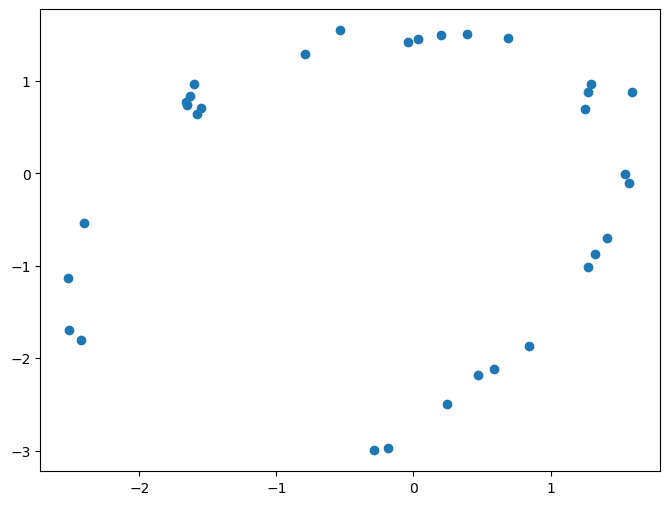

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(latent[:, 0].cpu(), latent[:, 1].cpu())